In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("/sales_data.csv")

In [ ]:
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

First 5 rows:
   order_id        date customer_id  product     category  price  quantity  \
0         1  2024-01-02        C101   Laptop  Electronics  60000         1   
1         2  2024-01-03        C102    Phone  Electronics  20000         2   
2         3  2024-01-05        C103    Shoes      Fashion   3000         1   
3         4  2024-01-07        C104  T-shirt      Fashion   1200         3   
4         5  2024-01-10        C105    Watch  Accessories   5000         1   

        city payment_method  
0  Hyderabad    Credit Card  
1     Mumbai            UPI  
2      Delhi           Cash  
3  Bangalore            UPI  
4    Chennai     Debit Card  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        30 non-null     int64 
 1   date            30 non-null     object
 2   customer_id     30 non-null     object


In [ ]:
df['date'] = pd.to_datetime(df['date'])

# Create new columns
df['revenue'] = df['price'] * df['quantity']
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')

In [ ]:
print("\nCategory Counts:")
print(df['category'].value_counts())


Category Counts:
category
Electronics    15
Fashion        10
Accessories     5
Name: count, dtype: int64


In [ ]:
print("\nPayment Method Counts:")
print(df['payment_method'].value_counts())



Payment Method Counts:
payment_method
UPI            10
Credit Card     9
Debit Card      6
Cash            5
Name: count, dtype: int64


In [ ]:
category_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
print("\nRevenue by Category:")
print(category_revenue)



Revenue by Category:
category
Electronics    606200
Fashion         48600
Accessories     42000
Name: revenue, dtype: int64


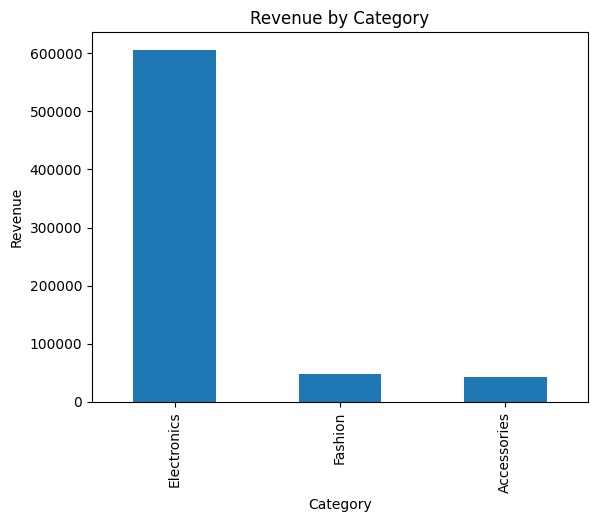

In [ ]:
category_revenue.plot(kind='bar')
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.savefig('revenue_by_category.png') # Save the plot
plt.show()

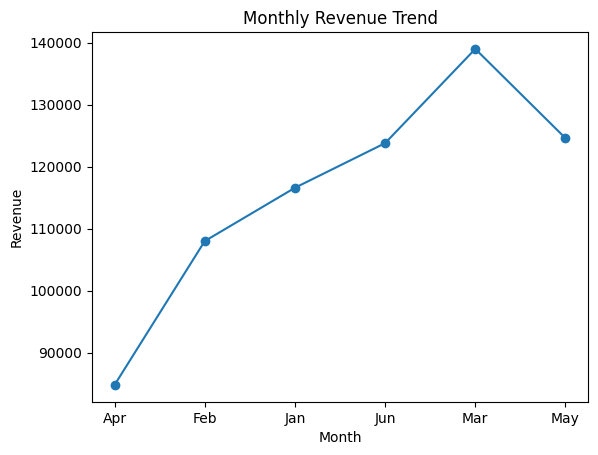

In [ ]:
monthly_revenue = df.groupby('month_name')['revenue'].sum()

monthly_revenue.plot(kind='line', marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


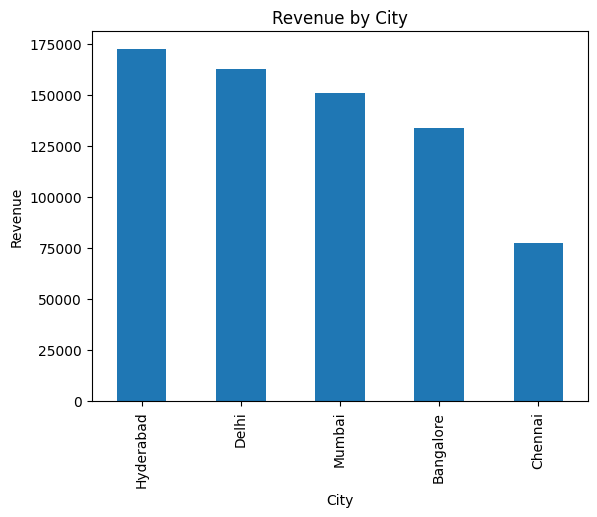

In [ ]:
city_revenue = df.groupby('city')['revenue'].sum().sort_values(ascending=False)

city_revenue.plot(kind='bar')
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

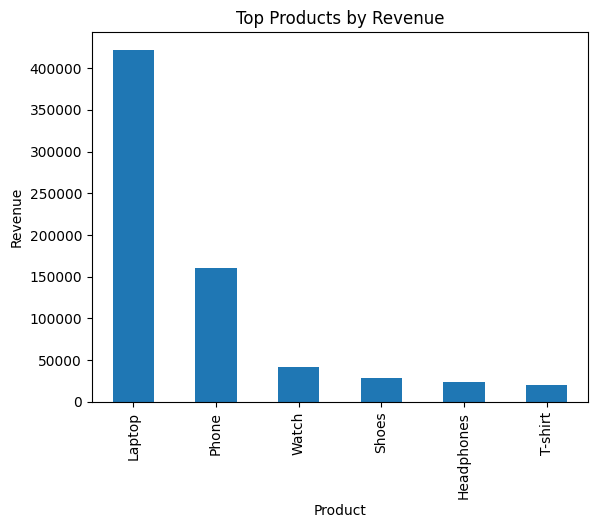

In [ ]:
top_products = df.groupby('product')['revenue'].sum().sort_values(ascending=False)

top_products.plot(kind='bar')
plt.title("Top Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()


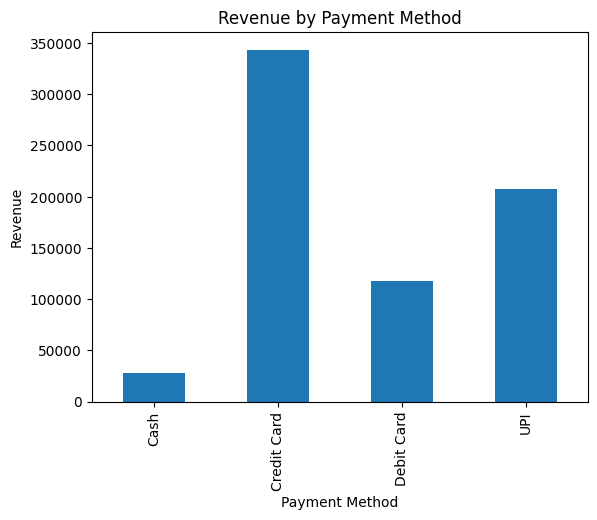

In [ ]:
payment_revenue = df.groupby('payment_method')['revenue'].sum()

payment_revenue.plot(kind='bar')
plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.show()


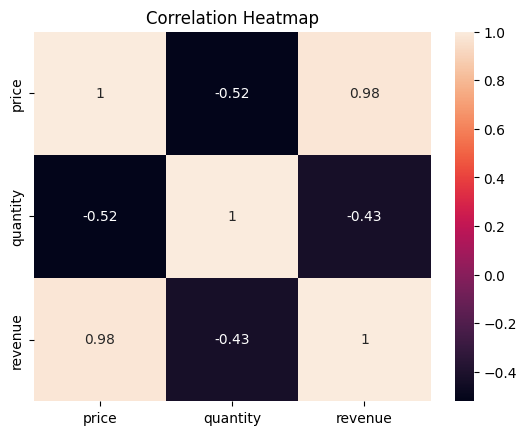

In [ ]:
sns.heatmap(df[['price','quantity','revenue']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print("\nKey Insights:")

print("- Top Category:", category_revenue.idxmax())
print("- Top City:", city_revenue.idxmax())
print("- Most Used Payment Method:", df['payment_method'].mode()[0])
print("- Highest Revenue Product:", top_products.idxmax())


Key Insights:
- Top Category: Electronics
- Top City: Hyderabad
- Most Used Payment Method: UPI
- Highest Revenue Product: Laptop


In [ ]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False)

30

In [ ]:
query = """
SELECT category, SUM(price * quantity) AS revenue
FROM sales
GROUP BY category
ORDER BY revenue DESC;
"""

pd.read_sql(query, conn)

,category,revenue
0,Electronics,606200
1,Fashion,48600
2,Accessories,42000


In [ ]:
query = """
SELECT product, SUM(price * quantity) AS revenue
FROM sales
GROUP BY product
ORDER BY revenue DESC;
"""
pd.read_sql(query, conn)

,product,revenue
0,Laptop,422000
1,Phone,161000
2,Watch,42000
3,Shoes,28000
4,Headphones,23200
5,T-shirt,20600


In [ ]:
query = """
SELECT strftime('%m', date) AS month, SUM(price * quantity) AS revenue
FROM sales
GROUP BY month;
"""
pd.read_sql(query, conn)

,month,revenue
0,01,116600
1,02,108000
2,03,139000
3,04,84800
4,05,124600
5,06,123800


In [ ]:
query = """
SELECT city, SUM(price * quantity) AS revenue
FROM sales
GROUP BY city
ORDER BY revenue DESC;
"""
pd.read_sql(query, conn)

,city,revenue
0,Hyderabad,172400
1,Delhi,162800
2,Mumbai,150600
3,Bangalore,133600
4,Chennai,77400


In [ ]:
query = """
SELECT payment_method, COUNT(*) AS usage_count
FROM sales
GROUP BY payment_method;
"""
pd.read_sql(query, conn)

,payment_method,usage_count
0,Cash,5
1,Credit Card,9
2,Debit Card,6
3,UPI,10


In [ ]:
query = """
SELECT AVG(price * quantity) AS avg_order_value FROM sales;
"""
pd.read_sql(query, conn)

,avg_order_value
0,23226.666667
